In [1]:
#%%
import sys


# Add the path where your Python packages are located
sys.path.append('/home/shij0d/Documents/Dis_Spatial')

import unittest
import torch
from scipy.optimize import minimize
from src.estimation_torch import GPPEstimation  # Assuming your class is defined in gppestimation.py
from src.generation import GPPSampleGenerator
from sklearn.gaussian_process.kernels import Matern
import math
from src.kernel import exponential_kernel,onedif_kernel
from src.networks import generate_connected_erdos_renyi_graph
from src.weights import optimal_weight_matrix
import networkx as nx
import numpy as np
import random
import pickle
from functools import partial
import multiprocessing
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

In [2]:
alpha=1
length_scale=0.1
nu=0.5
N=9000
mis_dis=0.02
l=math.sqrt(2*N)*mis_dis
extent=-l/2,l/2,-l/2,l/2,
coefficients=(-1,2,3,-2,1)
noise_level=2
J=9
con_pro=0.5
er = generate_connected_erdos_renyi_graph(J, con_pro)
adj_matrix=nx.adjacency_matrix(er).todense()
np.fill_diagonal(adj_matrix, 1)
weights,_=optimal_weight_matrix(adj_matrix=adj_matrix)
weights=torch.tensor(weights,dtype=torch.double)
    #weights = torch.ones((J,J),dtype=torch.float64)/J

kernel=alpha*Matern(length_scale=length_scale,nu=nu)
sampler=GPPSampleGenerator(num=N,min_dis=mis_dis,extent=extent,kernel=kernel,coefficients=coefficients,noise=noise_level,seed=2024)
data,knots=sampler.generate_obs_gpp(m=100,method="random")


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


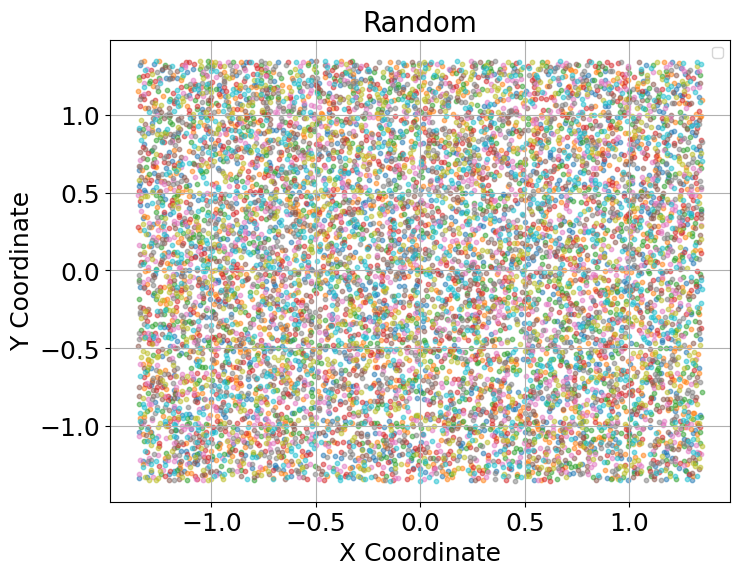

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


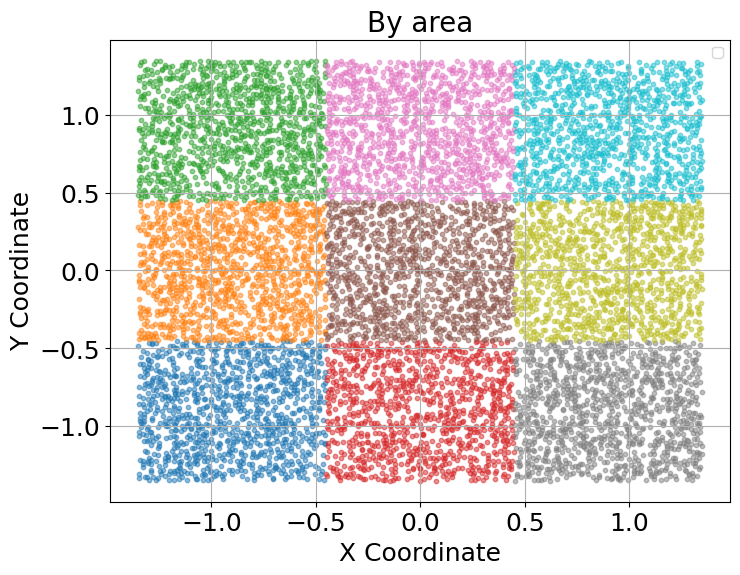

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


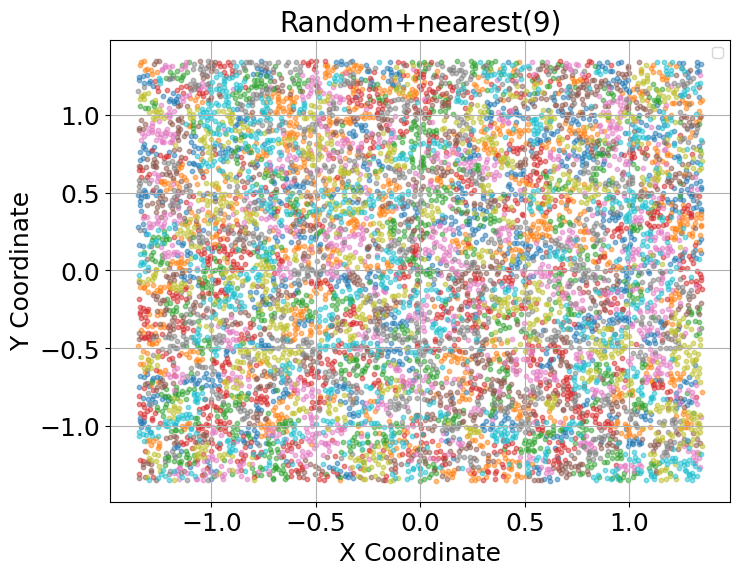

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


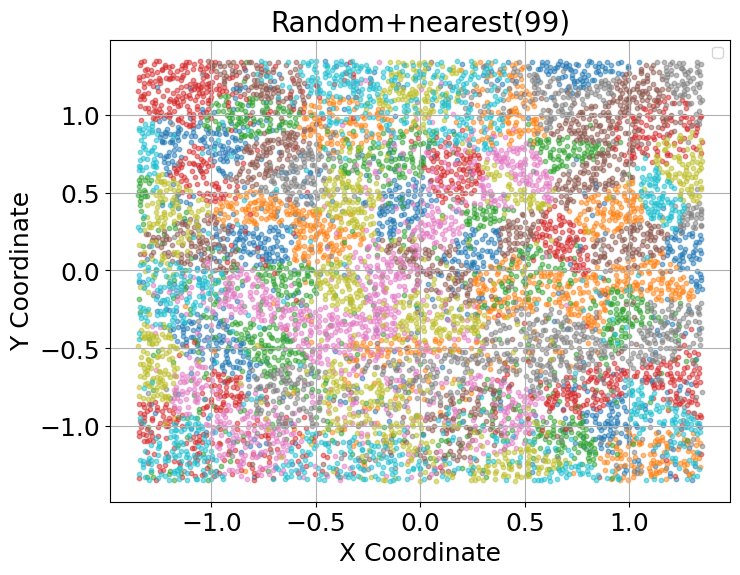

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


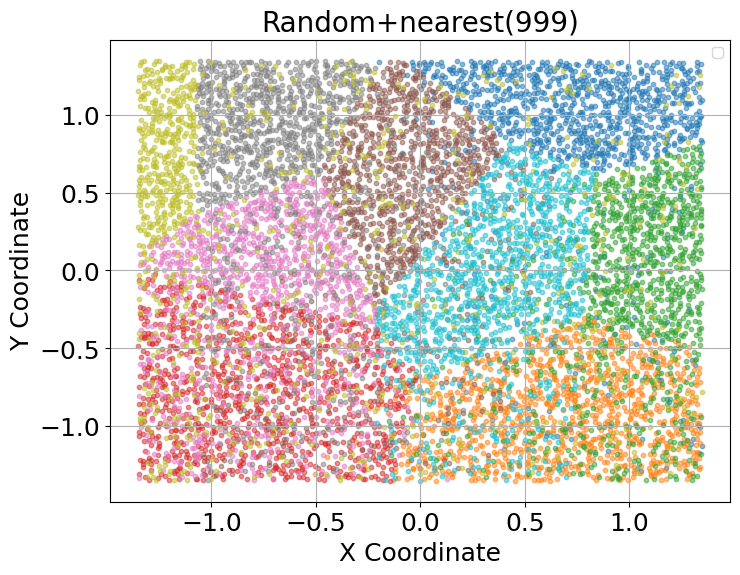

In [4]:
partition_method='random'
dis_data=sampler.data_split(data,J,partition_method)
GPPSampleGenerator.visual_locations(dis_data,f'/home/shij0d/Documents/Dis_Spatial/expriements/decentralized/partition/{partition_method}_locations.pdf','Random')

partition_method='by_area'
dis_data=sampler.data_split(data,J,partition_method)
GPPSampleGenerator.visual_locations(dis_data,f'/home/shij0d/Documents/Dis_Spatial/expriements/decentralized/partition/{partition_method}_locations.pdf','By area')

partition_method='random_nearest'
neighours=9
dis_data=sampler.data_split(data,J,partition_method,neighbours=neighours)
GPPSampleGenerator.visual_locations(dis_data,f'/home/shij0d/Documents/Dis_Spatial/expriements/decentralized/partition/{partition_method}_{neighours}_locations.pdf','Random+nearest(9)')

partition_method='random_nearest'
neighours=99
dis_data=sampler.data_split(data,J,partition_method,neighbours=neighours)
GPPSampleGenerator.visual_locations(dis_data,f'/home/shij0d/Documents/Dis_Spatial/expriements/decentralized/partition/{partition_method}_{neighours}_locations.pdf','Random+nearest(99)')

partition_method='random_nearest'
neighours=999
dis_data=sampler.data_split(data,J,partition_method,neighbours=neighours)
GPPSampleGenerator.visual_locations(dis_data,f'/home/shij0d/Documents/Dis_Spatial/expriements/decentralized/partition/{partition_method}_{neighours}_locations.pdf','Random+nearest(999)')